In [20]:
from cassandra.cluster import Cluster
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CASSANDRA_HOST  = "127.0.0.1"
KEYSPACE        = "bfh"
TABLE           = "sensor"

cluster = Cluster([CASSANDRA_HOST])
session = cluster.connect(KEYSPACE)

In [21]:
SENSOR_ID  = "gyro_x"
DAY_BUCKET = date(2026, 3, 21)

query_stmt = session.prepare(f"""
    SELECT ts, lx FROM {TABLE}
    WHERE sensor_id = ?
      AND day_bucket = ?
    ORDER BY ts ASC
""")

def fetch_data():
    rows = session.execute(query_stmt, (SENSOR_ID, DAY_BUCKET))
    timestamps = []
    values = []
    for row in rows:
        timestamps.append(row.ts)
        values.append(row.lx)
    return timestamps, values

ts_test, lx_test = fetch_data()
print(f"Rows fetched: {len(ts_test)}")
if ts_test:
    print(f"  First: {ts_test[0]}  lx={lx_test[0]}")
    print(f"  Last:  {ts_test[-1]}  lx={lx_test[-1]}")

Rows fetched: 2022
  First: 2026-03-21 19:11:14.180000  lx=0.32561
  Last:  2026-03-21 19:18:30.933000  lx=-2.63362


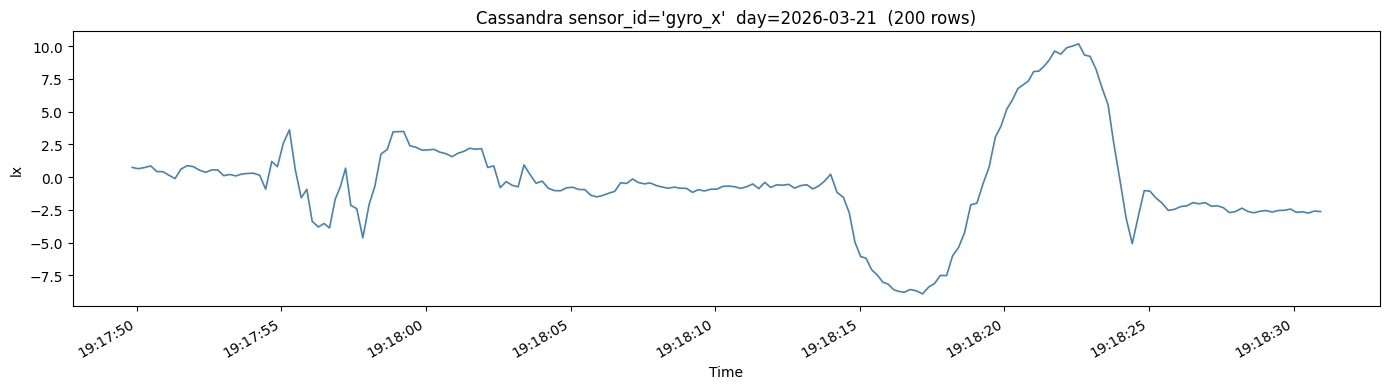

In [22]:
timestamps, values = fetch_data()

timestamps = timestamps[-200:]
values     = values[-200:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps, values, linewidth=1.2, color="steelblue")
ax.set_title(f"Cassandra sensor_id='{SENSOR_ID}'  day={DAY_BUCKET}  ({len(timestamps)} rows)")
ax.set_xlabel("Time")
ax.set_ylabel("lx")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()